# Arabic Fake News Detection — Fine-tuning XLM-RoBERTa

**Goal:** fine-tune `xlm-roberta-base` as a binary classifier that separates
real Arabic news articles from fake ones.

**Data:** `fake_news_dataset_10k.json` (label = 1) and `real_news_dataset_10k.json` (label = 0),
~10,000 articles each, ~20,000 articles total.

**How to use this notebook:** run the cells in order from top to bottom. Each section
starts with a short explanation of *what* we are doing and *why*, before the code that does it.
The final chapter, **"Understanding Every Line of the Fine-tuning Code"**, revisits the
most important code blocks and explains them line by line so this notebook works as a
learning resource, not just a script.

---


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Section 1 — Libraries

We need four families of tools:

- **Data handling:** `pandas`, `numpy`, `json` — to load and manipulate the two datasets.
- **Modeling:** `transformers`, `torch`, `datasets` — to load XLM-RoBERTa, tokenize text,
  and run training with the Hugging Face `Trainer`.
- **Splitting & metrics:** `scikit-learn` — for the stratified train/val/test split and for
  accuracy, precision, recall, F1, confusion matrix, ROC/AUC.
- **Visualization:** `matplotlib`, `seaborn` — to plot the confusion matrix and ROC curve.

Run the install cell once (it's safe to re-run; `pip` will just confirm the packages are
already there).


In [ ]:
# Run once. --quiet keeps the output short; --break-system-packages is needed on some
# managed environments (e.g. Colab/Docker images that protect the system Python).
!pip install -q --break-system-packages transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate


In [ ]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, classification_report
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)

# Reproducibility: fixing every relevant seed so re-running this notebook gives the
# same split, the same shuffling, and (as close as GPU non-determinism allows) the same
# training trajectory.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


## Section 2 — Load

We load the two raw JSON files into pandas DataFrames. At this stage we don't touch labels
yet — that happens in Section 3 when we merge them. We just need to see the shape and the
fields available (e.g. `title`, `text`, `content` — the exact key names depend on your
JSON structure, so we inspect the first record before assuming a column name).


In [ ]:
with open("/content/drive/MyDrive/fake_news_dataset_10k.json", "r", encoding="utf-8") as f:
    fake_data = json.load(f)
    # Accès à la clé 'articles' d'après la structure du fichier
    fake_raw = fake_data.get('articles', [])

with open("/content/drive/MyDrive/Real_news_dataset_10k.json", "r", encoding="utf-8") as f:
    real_data = json.load(f)
    # Accès à la clé 'articles' d'après la structure du fichier
    real_raw = real_data.get('articles', [])

print(f"Fake articles loaded: {len(fake_raw)}")
print(f"Real articles loaded: {len(real_raw)}")
print("\nSample fake record:")
print(fake_raw[0] if fake_raw else "No data")

Fake articles loaded: 10000
Real articles loaded: 10000

Sample fake record:
{'published_date': '2021-03-20', 'title': 'تعيين مدير جديد لمركب الحجار للحديد والصلب', 'text': 'عين المجمع الصناعي ايميطال لطفي كمال مانع مديرا عاما جديدا لمركب سيدار الحجار بعنابة خلفا لرضا بلحاج الذي أنهيت مهامه، حسبما علم السبت من خلية الاتصال لذات المجمع الصناعي.\nوقد شغل لطفي كمال مانع عدة مناصب كإطار مسير مختص في الجوانب التقنية المرتبطة بصناعة الحديد والصلب بمركب سيدار الحجار التابع للمجمع الصناعي ايميطال لفترة تجاوزت العشرين سنة قبل أن يعين مديرا عاما بالنيابة ثم مديرا عاما للمركب، حسب ذات المصدر الذي أوضح بأن هذا التعيين "يندرج في إطار المساعي الرامية إلى إعطاء نفس جديد للمركب لتحقيق الأهداف الاقتصادية المسطرة لمركب سيدار الحجار".يذكر أن مركب سيدار الحجار الذي يشغل 6 آلاف عامل قد حددت قدرته الإنتاجية للسنة الجارية 2021 بما لا يقل عن 750 ألف طن من مختلف المنتجات الحديدية.\nأ.ش.د', 'category': 'Economy', 'category_score': 5, 'matched_keywords': ['اقتصاد', 'اقتصادية', 'اقتصادي', 'الاقتصاد', 'الإنتاج'], 

In [ ]:
df_fake = pd.DataFrame(fake_raw)
df_real = pd.DataFrame(real_raw)

print("Fake dataframe columns:", list(df_fake.columns))
print("Real dataframe columns:", list(df_real.columns))
df_fake.head(3)


Fake dataframe columns: ['published_date', 'title', 'text', 'category', 'category_score', 'matched_keywords', 'label']
Real dataframe columns: ['published_date', 'title', 'text', 'label', 'category', 'category_score', 'matched_keywords']


,published_date,title,text,category,category_score,matched_keywords,label
0,2021-03-20,تعيين مدير جديد لمركب الحجار للحديد والصلب,عين المجمع الصناعي ايميطال لطفي كمال مانع مدير...,Economy,5,"[اقتصاد, اقتصادية, اقتصادي, الاقتصاد, الإنتاج]",Fake
1,2021-03-06,رئيس وزراء باكستان يفوز بتصويت على الثقة قاطعت...,نجا رئيس الوزراء الباكستاني، عمران خان، السبت،...,Politics,40,"[رئيس, الرئيس, الحكومة, حكومة, وزير, البرلمان,...",Fake
2,2021-05-13,تكريم أسر شهداء القطاع الطبي بالمستشفيات الجام...,قدم الدكتور خالد عبدالغفار وزير التعليم العالي...,Politics,19,"[رئيس, الرئيس, وزير, وزارة, الدولة, الجيش, الد...",Fake


> **Note:** if your JSON uses a different text field name than `text` (e.g. `article`,
> `content`, `body`), update the `TEXT_COL` variable below — every later cell reads from it,
> so you only need to change it in one place.


In [ ]:
TEXT_COL = "text"   # <-- change this if your JSON field has a different name

assert TEXT_COL in df_fake.columns, f"'{TEXT_COL}' not found in fake dataset columns: {list(df_fake.columns)}"
assert TEXT_COL in df_real.columns, f"'{TEXT_COL}' not found in real dataset columns: {list(df_real.columns)}"


## Section 3 — Merge Datasets

We now attach the label that the model will learn to predict:

```
Fake  ──►  label = 1
Real  ──►  label = 0
```

Why this direction and not the opposite? It's a convention choice — there's no mathematical
reason 1 must mean "fake." We pick **1 = fake** because in a fraud/misinformation-detection
framing, the "positive class" is usually the thing you're trying to *catch*, which makes
precision/recall read naturally: *"precision on the positive class"* = *"of the articles we
flagged as fake, how many really were?"*

After labeling, we concatenate both DataFrames into one and shuffle rows, so the model never
sees a long uninterrupted run of only-fake or only-real examples during training.


In [ ]:
df_fake["label"] = 1   # fake
df_real["label"] = 0   # real

df = pd.concat([df_fake[[TEXT_COL, "label"]], df_real[[TEXT_COL, "label"]]], ignore_index=True)
df = df.rename(columns={TEXT_COL: "text"})

# Drop empty / null articles — an empty string tokenizes to almost nothing and just
# injects noise into training.
before = len(df)
df = df[df["text"].notna() & (df["text"].str.strip().str.len() > 0)].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty/null rows")

# Shuffle so fake/real examples are interleaved, not in two solid blocks.
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total articles: {len(df)}")
print(df["label"].value_counts().rename({0: "real (0)", 1: "fake (1)"}))
df.head(3)


Dropped 0 empty/null rows
Total articles: 20000
label
real (0)    10000
fake (1)    10000
Name: count, dtype: int64


,text,label
0,قدم الصندوق الوطني للتعاون الفلاحي، 20 حصة مجا...,0
1,قالت النائب مرزوق الخليفة إن قرارات سلمان الحم...,1
2,التقارب التركي المصري.. وفد تركي إلى القاهرة م...,1


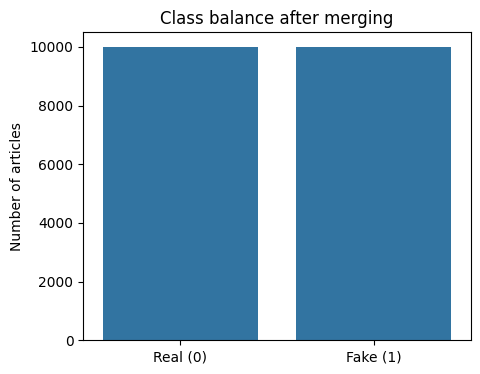

In [ ]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["Real (0)", "Fake (1)"])
plt.title("Class balance after merging")
plt.ylabel("Number of articles")
plt.xlabel("")
plt.show()


## Section 4 — Train / Validation / Test Split

```
Train : 80%
Val   : 10%
Test  : 10%
```

### Why 80/10/10 instead of 70/15/15?

With ~20,000 articles total, the difference between the two schemes comes down to how many
examples end up in each bucket:

| Split scheme | Train | Val | Test |
|---|---|---|---|
| 80/10/10 | ~16,000 | ~2,000 | ~2,000 |
| 70/15/15 | ~14,000 | ~3,000 | ~3,000 |

Two reasons we prefer 80/10/10 here:

1. **XLM-RoBERTa is a large pretrained model, not something learning from scratch.**
   Fine-tuning only adjusts existing weights (plus a small new classification head), so it
   needs comparatively less data to converge than training a model from random
   initialization would. The *marginal* value of an extra training example is lower than the
   value of that same example sitting in train rather than in an already-adequate
   validation/test set.
2. **2,000 examples is already enough for stable validation/test metrics.** With a roughly
   balanced binary task, a 2,000-example test set gives a 95% confidence interval on accuracy
   of about ±1.5–2 points — precise enough to compare hyperparameter choices meaningfully.
   Going to 3,000 tightens that interval only marginally, at the real cost of ~2,000 fewer
   training examples (a ~14% cut to the training set).

In short: once validation/test sets are "big enough" to give trustworthy metrics, additional
held-out data has diminishing returns — while training data for a large transformer keeps
paying off longer. 80/10/10 spends the data budget where it matters more.

### Why stratified splitting?

A plain random split can, by chance, shift the fake/real ratio between train and test
(e.g. 52/48 in train but 46/54 in test). `stratify=` forces **every split to preserve the
original class proportions**, so validation and test performance genuinely reflects the
model's behavior on the same distribution it was trained on — not an artifact of an
imbalanced split.


In [ ]:
# First split off the test set (10%), stratified on label.
train_val_df, test_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df["label"],
    random_state=SEED,
)

# Then split the remaining 90% into train (80% of total) and val (10% of total).
# 0.10 / 0.90 = 0.1111... -> this fraction of the remaining 90% equals 10% of the original total.
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.10 / 0.90,
    stratify=train_val_df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):>6} ({len(train_df)/len(df):.1%})")
print(f"Val:   {len(val_df):>6} ({len(val_df)/len(df):.1%})")
print(f"Test:  {len(test_df):>6} ({len(test_df)/len(df):.1%})")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    ratio = split["label"].mean()
    print(f"{name:>6} fake ratio: {ratio:.3f}")


Train:  15999 (80.0%)
Val:     2001 (10.0%)
Test:    2000 (10.0%)
 Train fake ratio: 0.500
   Val fake ratio: 0.500
  Test fake ratio: 0.500


## Section 5 — Load Tokenizer

We use the tokenizer that ships with `xlm-roberta-base`. XLM-RoBERTa was pretrained on 100
languages including Arabic, using a **SentencePiece** subword vocabulary — this matters
because Arabic morphology is rich (many prefixes/suffixes attach to a root), and a
subword tokenizer can represent unseen word forms as combinations of known pieces instead
of mapping them all to a generic "unknown word" token.

**Every line explained:**


In [ ]:
MODEL_NAME = "xlm-roberta-base"

# AutoTokenizer inspects MODEL_NAME's config and downloads/loads the matching tokenizer
# class (here, XLMRobertaTokenizerFast) along with its vocabulary and SentencePiece model.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Why "Fast"? The Rust-backed fast tokenizer is what AutoTokenizer returns by default when
# available. It's needed later for `return_offsets_mapping` and for batched tokenization
# to run fast enough to process ~16,000 training articles without becoming a bottleneck.
print(type(tokenizer))

# Vocabulary size: how many distinct subword tokens the model understands.
print(f"Vocabulary size: {tokenizer.vocab_size}")

# Special tokens the model was pretrained with:
print(f"CLS token: {tokenizer.cls_token} (id={tokenizer.cls_token_id})")
print(f"SEP token: {tokenizer.sep_token} (id={tokenizer.sep_token_id})")
print(f"PAD token: {tokenizer.pad_token} (id={tokenizer.pad_token_id})")
print(f"UNK token: {tokenizer.unk_token} (id={tokenizer.unk_token_id})")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

<class 'transformers.models.xlm_roberta.tokenization_xlm_roberta.XLMRobertaTokenizer'>
Vocabulary size: 250002
CLS token: <s> (id=0)
SEP token: </s> (id=2)
PAD token: <pad> (id=1)
UNK token: <unk> (id=3)


- `MODEL_NAME = "xlm-roberta-base"` — pins the exact checkpoint. Using a variable (not a
  hardcoded string sprinkled everywhere) means Sections 5, 7, 10, and 12 all stay in sync if
  you ever switch to `xlm-roberta-large`.
- `AutoTokenizer.from_pretrained(...)` — downloads (or loads from local cache) the
  vocabulary file and merge rules, so tokenization is byte-for-byte identical to what the
  model saw during its own pretraining. **This must always match the model checkpoint** —
  mixing a different tokenizer with this model would silently scramble token IDs.
- `CLS` (`<s>`) is prepended to every sequence — its final hidden state is what the
  classification head reads (see Section 7).
- `SEP` (`</s>`) marks the end of a sequence.
- `PAD` (`<pad>`) fills shorter sequences up to a fixed length inside a batch, since GPUs
  require uniformly-shaped tensors.
- `UNK` (`<unk>`) is the fallback for any character sequence the SentencePiece model truly
  cannot decompose — rare in practice because subword tokenization can always fall back to
  smaller and smaller pieces.


## Section 6 — Tokenization

We now visualize what tokenization does to a **real Arabic article from your dataset**,
following the pipeline:

```
Sentence  ─►  Tokens  ─►  IDs  ─►  Attention Mask
```


In [ ]:
sample_text = train_df.iloc[0]["text"]
sample_label = train_df.iloc[0]["label"]

print("Original sentence (truncated to 200 chars):")
print(sample_text[:200], "...")
print(f"\nTrue label: {'fake' if sample_label == 1 else 'real'}")


Original sentence (truncated to 200 chars):
أكّدت الناطقة الرسمية باسم الحكومة حسناء بن سليمان، خلال حضورها اليوم الأربعاء 5 ماي 2021 على قناة "نسمة"، أن فرضية إعلان الحجر الصحي الشامل خلال أيام عيد الفطر مطروحة. وكان عضو اللجنة العلمية لمجابهة ...

True label: fake


In [ ]:
# Step 1: Sentence -> Tokens (subword pieces, human-readable)
tokens = tokenizer.tokenize(sample_text)
print("Step 1 — Tokens (first 20):")
print(tokens[:20])


Step 1 — Tokens (first 20):
['▁أك', 'ّ', 'دت', '▁النا', 'طق', 'ة', '▁الرسمية', '▁باسم', '▁الحكومة', '▁حسن', 'اء', '▁بن', '▁سليمان', '،', '▁خلال', '▁حضور', 'ها', '▁اليوم', '▁الأربعاء', '▁5']


In [ ]:
# Step 2: Tokens -> IDs (integers the model actually consumes)
ids = tokenizer.convert_tokens_to_ids(tokens)
print("Step 2 — Token IDs (first 20):")
print(ids[:20])


Step 2 — Token IDs (first 20):
[95695, 1168, 37674, 59721, 72712, 250, 130394, 73397, 33654, 14859, 2689, 2567, 160218, 50, 5784, 10960, 608, 7089, 30725, 190]


In [ ]:
# Step 3: Full encoding, as it will be fed to the model: adds CLS/SEP, pads/truncates to
# MAX_LEN, and produces the attention mask.
MAX_LEN = 256  # see justification below

encoded = tokenizer(
    sample_text,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

print("Step 3 — input_ids (first 20):", encoded["input_ids"][0][:20].tolist())
print("Step 3 — attention_mask (first 20):", encoded["attention_mask"][0][:20].tolist())
print(f"\ninput_ids shape: {encoded['input_ids'].shape}")

# Decode back to text to sanity-check that CLS/SEP were added correctly.
print("\nDecoded back to text (sanity check):")
print(tokenizer.decode(encoded["input_ids"][0][:20]))


Step 3 — input_ids (first 20): [0, 95695, 1168, 37674, 59721, 72712, 250, 130394, 73397, 33654, 14859, 2689, 2567, 160218, 50, 5784, 10960, 608, 7089, 30725]
Step 3 — attention_mask (first 20): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

input_ids shape: torch.Size([1, 256])

Decoded back to text (sanity check):
<s> أكّدت الناطقة الرسمية باسم الحكومة حسناء بن سليمان، خلال حضورها اليوم الأربعاء


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (864 > 512). Running this sequence through the model will result in indexing errors


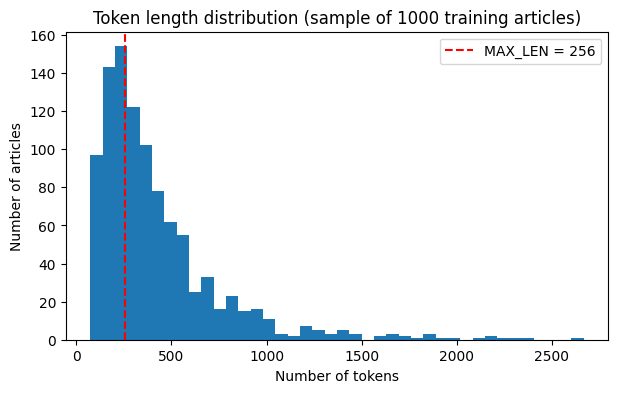

Fraction of sampled articles truncated at 256 tokens: 62.8%


In [ ]:
# Why MAX_LEN = 256? Check the actual token-length distribution of the training articles —
# picking MAX_LEN from real data, not guessing, avoids truncating most articles (too small)
# or wasting compute padding everything to an unnecessarily long sequence (too large).
sample_lengths = [len(tokenizer.encode(t)) for t in train_df["text"].sample(1000, random_state=SEED)]

plt.figure(figsize=(7, 4))
plt.hist(sample_lengths, bins=40)
plt.axvline(256, color="red", linestyle="--", label="MAX_LEN = 256")
plt.title("Token length distribution (sample of 1000 training articles)")
plt.xlabel("Number of tokens")
plt.ylabel("Number of articles")
plt.legend()
plt.show()

pct_over = (np.array(sample_lengths) > 256).mean()
print(f"Fraction of sampled articles truncated at 256 tokens: {pct_over:.1%}")


Adjust `MAX_LEN` based on the histogram above:
- If well under 5% of articles are truncated, 256 is a reasonable trade-off between coverage
  and speed/memory.
- If truncation is much higher (e.g. your articles are full-length news pieces, not short
  snippets), consider `MAX_LEN = 384` or `512` — the ceiling XLM-RoBERTa supports — at the
  cost of slower training and more GPU memory per batch.


## Section 7 — Load XLM-RoBERTa

`xlm-roberta-base` as published is a general-purpose *masked language model* — it has no
idea yet what "fake" or "real" means. `AutoModelForSequenceClassification` takes the
pretrained encoder and attaches a **classification head** on top:

```
[Pretrained XLM-RoBERTa encoder]
              │
     hidden state of the [CLS] token
              │
      Linear layer (hidden_size → hidden_size)
              │
             tanh
              │
            Dropout
              │
      Linear layer (hidden_size → num_labels)
              │
           logits (2 numbers: real-score, fake-score)
```

### Why add a classification head at all?

The pretrained encoder produces one contextual vector *per token* — it was trained to
predict masked words, not to output a single "fake/real" decision. The classification head
is the small, **randomly initialized** piece that learns to map the encoder's summary
representation (the `[CLS]` vector, which attention lets absorb information from the whole
article) into the 2 class scores we actually want. During fine-tuning, both the pretrained
encoder weights *and* this new head are updated — the encoder is nudged from "language
understanding in general" toward "language understanding useful for spotting fake news,"
while the head learns the mapping essentially from scratch.


In [ ]:
LABEL2ID = {"real": 0, "fake": 1}
ID2LABEL = {0: "real", 1: "fake"}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     278,045,186
Trainable parameters: 278,045,186


> You'll notice a warning when this cell runs, similar to:
> *"Some weights of XLMRobertaForSequenceClassification were not initialized from the model
> checkpoint... You should probably TRAIN this model on a down-stream task."*
> This is expected — it's exactly the classification head described above, which has no
> pretrained weights because it didn't exist before you asked for `num_labels=2`. Training
> in Section 8 is what teaches it.


## Section 8 — Training

First we wrap our DataFrames in a PyTorch `Dataset`, then configure every hyperparameter
the `Trainer` needs, explaining *why* each value was chosen — not just what it does.


In [ ]:
class NewsDataset(Dataset):
    """Wraps a DataFrame of (text, label) pairs and tokenizes lazily, one example at a
    time. Lazy (on-the-fly) tokenization keeps memory usage flat regardless of dataset
    size — we don't hold ~16,000 fully-tokenized tensors in RAM at once."""

    def __init__(self, dataframe, tokenizer, max_len):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }


train_dataset = NewsDataset(train_df, tokenizer, MAX_LEN)
val_dataset = NewsDataset(val_df, tokenizer, MAX_LEN)
test_dataset = NewsDataset(test_df, tokenizer, MAX_LEN)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val dataset size:   {len(val_dataset)}")
print(f"Test dataset size:  {len(test_dataset)}")


Train dataset size: 15999
Val dataset size:   2001
Test dataset size:  2000


In [ ]:
def compute_metrics(eval_pred):
    """Called by the Trainer after every evaluation pass (i.e. at the end of each epoch,
    per eval_strategy below). Converts raw logits into the metrics we actually care about,
    so training progress is visible in terms of accuracy/F1 rather than opaque loss values."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary", pos_label=1
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


### Hyperparameters — what and why

| Hyperparameter | Value | Why this value |
|---|---|---|
| `num_train_epochs` | **4** | Fine-tuning transformers typically converges in 2–5 passes over the data; the pretrained weights are already close to a good solution, so more epochs mostly risks overfitting on a ~16k-example dataset rather than helping. `load_best_model_at_end` + early stopping (below) protects us if 4 turns out to be one epoch too many. |
| `learning_rate` | **2e-5** | This is the standard range (1e-5 to 5e-5) for fine-tuning RoBERTa-family models. Much higher (e.g. 1e-3, the typical rate for training from scratch) would wreck the pretrained weights in the first few steps; much lower would barely move them before training ends. |
| `weight_decay` | **0.01** | A small L2 penalty on the weights, discouraging any single weight from growing very large. This is a mild regularizer against overfitting — 0.01 is the standard value used in the original RoBERTa/BERT fine-tuning recipes. |
| `per_device_train_batch_size` | **16** | Balances GPU memory against gradient stability. Sequence length 256 with `xlm-roberta-base` fits comfortably in 16 GB of GPU memory at batch size 16; if you hit an out-of-memory error, drop to 8 and use gradient accumulation (see below) to keep the *effective* batch size the same. |
| `gradient_accumulation_steps` | **2** | Accumulates gradients over 2 batches before each optimizer step, giving an *effective* batch size of 16 × 2 = 32 — closer to the batch sizes (32–64) commonly reported to stabilize BERT-family fine-tuning — without needing the GPU memory a real batch of 32 would require. |
| `warmup_ratio` | **0.06** | Linearly ramps the learning rate up from 0 for the first 6% of training steps, then decays it. Fine-tuning without warmup risks a large, destabilizing gradient update in the very first steps, before the classification head (which starts randomly initialized) has learned anything sensible — warmup lets the head "settle" before the learning rate reaches its full value. |
| `eval_strategy` | **"epoch"** | We evaluate on the validation set once per epoch (rather than e.g. every N steps) — frequent enough to catch overfitting, without the overhead of evaluating constantly on a dataset this size. |
| `save_strategy` | **"epoch"** | Matched to `eval_strategy` — `load_best_model_at_end` requires save and eval to happen on the same schedule so the Trainer can compare checkpoints apples-to-apples. |
| `load_best_model_at_end` | **True** | After training finishes, reloads the checkpoint with the best validation F1 rather than whatever the *last* epoch happened to produce — protects against the last epoch being a slightly overfit one. |
| `metric_for_best_model` | **"f1"** | We optimize for F1 rather than accuracy because a fake-news classifier is used in a context where false negatives (fake news labeled real) and false positives (real news flagged as fake) both carry real cost — F1 balances precision and recall directly, whereas accuracy alone can look good even with a systematic bias toward one class. |


In [ ]:
OUTPUT_DIR = "./xlmr-fake-news-checkpoints"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    warmup_ratio=0.06,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,          # only keep the 2 most recent checkpoints on disk
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=50,
    fp16=torch.cuda.is_available(),   # mixed precision, only meaningful on GPU
    report_to="none",            # disables W&B/other loggers unless you set one up
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


`EarlyStoppingCallback(early_stopping_patience=2)` stops training if validation F1 doesn't
improve for 2 consecutive evaluations — a safety net in case `num_train_epochs=4` is more
than the data needs, without having to guess the "right" epoch count up front.


In [ ]:
train_result = trainer.train()

print("\nTraining complete.")
print(train_result.metrics)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.499720,0.433533,0.814093,0.859268,0.751000,0.801494
2,0.318733,0.485391,0.822589,0.858732,0.772000,0.813060


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Section 9 — Evaluation

We evaluate on the **test set** (held out and never touched during training or hyperparameter
choices) to get an unbiased read on real-world performance.


In [ ]:
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_true = predictions_output.label_ids
y_pred = np.argmax(logits, axis=1)

# Softmax to turn logits into probabilities — needed for the ROC curve / AUC below,
# which require a continuous score, not just the final 0/1 decision.
probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_score = probs[:, 1]   # probability assigned to the "fake" class


In [ ]:
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", pos_label=1)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}  (of articles predicted fake, how many really were)")
print(f"Recall:    {recall:.4f}  (of articles that really were fake, how many we caught)")
print(f"F1-score:  {f1:.4f}  (harmonic mean of precision and recall)")


Accuracy:  0.8530
Precision: 0.8091  (of articles predicted fake, how many really were)
Recall:    0.9240  (of articles that really were fake, how many we caught)
F1-score:  0.8627  (harmonic mean of precision and recall)


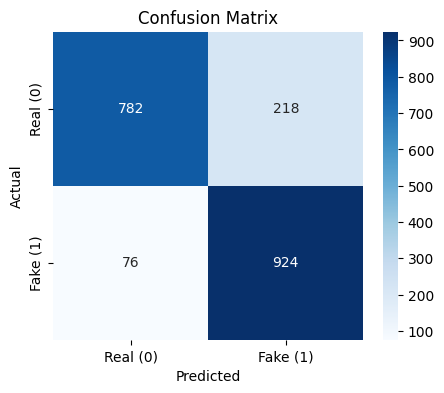

True Negatives  (real correctly kept):   782
False Positives (real flagged as fake):  218
False Negatives (fake missed as real):   76
True Positives  (fake correctly caught): 924


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real (0)", "Fake (1)"],
            yticklabels=["Real (0)", "Fake (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (real correctly kept):   {tn}")
print(f"False Positives (real flagged as fake):  {fp}")
print(f"False Negatives (fake missed as real):   {fn}")
print(f"True Positives  (fake correctly caught): {tp}")


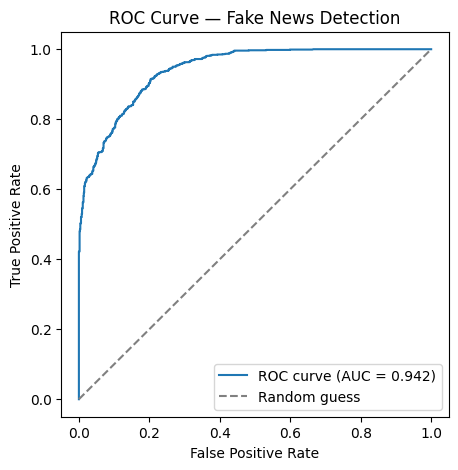

AUC: 0.9417


In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Fake News Detection")
plt.legend()
plt.show()

print(f"AUC: {roc_auc:.4f}")


In [ ]:
print(classification_report(y_true, y_pred, target_names=["real", "fake"]))


              precision    recall  f1-score   support

        real       0.91      0.78      0.84      1000
        fake       0.81      0.92      0.86      1000

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.85      0.85      2000



### Optimisation du Seuil de Décision
Par défaut, `argmax` utilise un seuil de 0.5. Testons différents seuils pour voir si nous pouvons augmenter le score F1 sur l'ensemble de test.

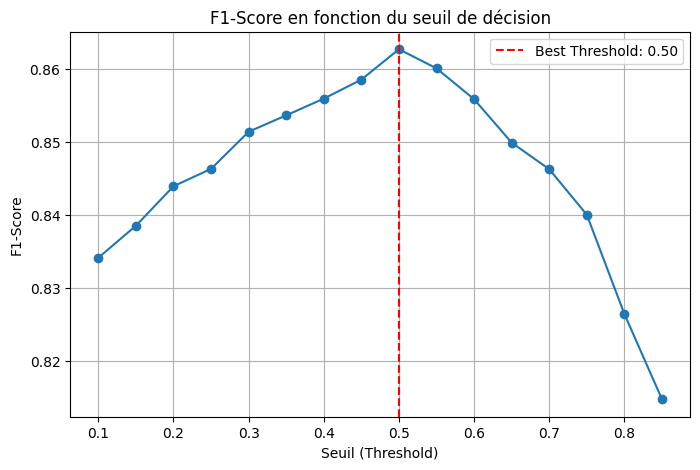

Meilleur seuil : 0.50 avec un F1-score de 0.8627


In [ ]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    y_pred_threshold = (y_score >= t).astype(int)
    _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred_threshold, average='binary')
    f1_scores.append(f1)

# Trouver le meilleur seuil
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.title("F1-Score en fonction du seuil de décision")
plt.xlabel("Seuil (Threshold)")
plt.ylabel("F1-Score")
plt.legend()
plt.grid(True)
plt.show()

print(f"Meilleur seuil : {best_threshold:.2f} avec un F1-score de {best_f1:.4f}")

### Analyse des erreurs
Identifions les exemples où le modèle est le plus confiant mais se trompe (erreurs critiques).

In [ ]:
test_results = test_df.copy()
test_results['prob_fake'] = y_score
test_results['prediction'] = y_pred

# Top 5 Faux Positifs (Réel prédit comme Fake avec haute confiance)
print("--- Top Faux Positifs ---")
display(test_results[(test_results['label'] == 0) & (test_results['prediction'] == 1)].sort_values(by='prob_fake', ascending=False).head(5))

# Top 5 Faux Négatifs (Fake prédit comme Réel avec haute confiance)
print("\n--- Top Faux Négatifs ---")
display(test_results[(test_results['label'] == 1) & (test_results['prediction'] == 0)].sort_values(by='prob_fake', ascending=True).head(5))

--- Top Faux Positifs ---


,text,label,prob_fake,prediction
718,"حقق المهر ""كنغ شلاع"" ملك سمو الشيخ عبدالله بن ...",0,0.995890,1
1658,تمنع العقوبات الأمريكية على كاراكاس شراء لقاحا...,0,0.995882,1
936,سيارات الإسعاف\nينشر القاهرة 24، أسماء المتوفي...,0,0.988928,1
1565,تجمع مئات المتظاهرين في ميناء أوكلاند بولاية ك...,0,0.987946,1
485,أثارت وفاة طفل، في الأسبوع السادس في رومانيا، ...,0,0.985243,1



--- Top Faux Négatifs ---


,text,label,prob_fake,prediction
527,كتبت: رضوى ايهاب\nيواجه الكثير من المخرجين أثن...,1,0.001636,0
584,نجران 03 شعبان 1442 ه الموافق 16 مارس 2021 م و...,1,0.002067,0
1534,زنقة 20. عن وكالة (أ.ف.ب)\nأكدت الوكالة الأمير...,1,0.002715,0
740,أعلنت نائبة رئيس الوزراء البلغاري بالوكالة، وز...,1,0.005180,0
700,فاركوفيت ب 12 منبه لوظيفة الكبد ، والكبد مسؤول...,1,0.013454,0


### Interpreting the results

- **Accuracy** tells you overall correctness, but is misleading if the classes are
  imbalanced — always read it alongside precision/recall.
- **Precision on "fake"** answers *"when the model says fake, can I trust it?"* — low
  precision means real articles get wrongly flagged, which erodes user trust in the system.
- **Recall on "fake"** answers *"of all the fake articles out there, how many does the model
  actually catch?"* — low recall means misinformation slips through undetected.
- **F1** is the balance between the two — useful as a single number for comparing model
  versions, but always check the confusion matrix too, since two models can share the same
  F1 while making very different *kinds* of mistakes.
- **AUC close to 1.0** means the model's fake-probability score reliably ranks fake articles
  above real ones across *all* possible decision thresholds — not just the default 0.5 cutoff
  `argmax` uses. A high AUC with a mediocre F1 at threshold 0.5 suggests the model is good but
  poorly calibrated at that particular cutoff, and adjusting the decision threshold
  (Section 11) could help.


## Section 10 — Save

We persist three things needed to reuse this model later, independent of this notebook or
this training run:

1. **Model weights** (the fine-tuned encoder + classification head)
2. **Tokenizer** (vocabulary + merge rules — must always travel with its matching model)
3. **Label mapping** (`{0: "real", 1: "fake"}`) — a small JSON file so any downstream code
   (e.g. the FastAPI service in Section 12) doesn't have to hardcode label meaning.


In [ ]:
SAVE_DIR = "./xlmr-fake-news-final"

trainer.save_model(SAVE_DIR)          # saves config.json + model weights (safetensors)
tokenizer.save_pretrained(SAVE_DIR)   # saves vocab, merges, tokenizer_config.json

label_mapping = {"id2label": ID2LABEL, "label2id": LABEL2ID}
with open(f"{SAVE_DIR}/label_mapping.json", "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)

print(f"Saved model, tokenizer, and label mapping to: {SAVE_DIR}")
import os
print(os.listdir(SAVE_DIR))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model, tokenizer, and label mapping to: ./xlmr-fake-news-final
['training_args.bin', 'tokenizer.json', 'config.json', 'label_mapping.json', 'model.safetensors', 'tokenizer_config.json']


## Section 11 — Inference

We reload from disk (proving the saved artifacts are self-contained) and classify first one
article, then several.


In [ ]:
inference_tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
inference_model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR)
inference_model.to(DEVICE)
inference_model.eval()

with open(f"{SAVE_DIR}/label_mapping.json", "r", encoding="utf-8") as f:
    loaded_mapping = json.load(f)
    ID2LABEL_LOADED = {int(k): v for k, v in loaded_mapping["id2label"].items()}

print("Model reloaded. Label mapping:", ID2LABEL_LOADED)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model reloaded. Label mapping: {0: 'real', 1: 'fake'}


In [ ]:
def classify_article(text, model, tokenizer, id2label, max_len=MAX_LEN, device=DEVICE):
    """Classify a single article and return the predicted label plus class probabilities."""
    encoding = tokenizer(
        text,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        logits = model(**encoding).logits
        probs = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

    pred_id = int(np.argmax(probs))
    return {
        "predicted_label": id2label[pred_id],
        "confidence": float(probs[pred_id]),
        "probabilities": {id2label[i]: float(p) for i, p in enumerate(probs)},
    }


# --- classify one article ---
example_article = test_df.iloc[0]["text"]
result = classify_article(example_article, inference_model, inference_tokenizer, ID2LABEL_LOADED)
print("Article (first 150 chars):", example_article[:150], "...")
print("Prediction:", result)


Article (first 150 chars): أنا معجب بالشروق بالفعل، لا تظهر هذه الرسالة مرة أخرى
سجّل إعجابك بصفحتنا على فيسبوك لتحصل على المزيد
أعجبك الموضوع؟ سجّل إعجابك بصفحتنا على فيسبوك لت ...
Prediction: {'predicted_label': 'real', 'confidence': 0.9987025260925293, 'probabilities': {'real': 0.9987025260925293, 'fake': 0.0012974586570635438}}


In [ ]:
# --- classify several articles at once ---
sample_articles = test_df.sample(5, random_state=SEED)

for i, row in sample_articles.iterrows():
    result = classify_article(row["text"], inference_model, inference_tokenizer, ID2LABEL_LOADED)
    true_label = ID2LABEL_LOADED[row["label"]]
    match = "✅" if result["predicted_label"] == true_label else "❌"
    print(f"{match} True: {true_label:>4} | Predicted: {result['predicted_label']:>4} "
          f"({result['confidence']:.1%} confidence) | {row['text'][:80]}...")


✅ True: fake | Predicted: fake (96.9% confidence) | "نحن نعيش زمن الوجبات السريعة" .."نحن في عصر الon line" الأمر ليس بغريب؛ فهي كلم...
✅ True: fake | Predicted: fake (91.0% confidence) | قال مكتب رئيس الوزراء الفرنسي إن فرنسا ستفرض حجرا صحيا صارما لمدة عشرة أيام لجمي...
✅ True: fake | Predicted: fake (100.0% confidence) | المستقلة/-علي قاسم الكعبي/..نفت مديرية شرطة ميسان ميسان، الجمعة، تعرض احد مراكزه...
✅ True: fake | Predicted: fake (57.5% confidence) | أعلن "راديو الضاحية الشمالية" في بلاغ أصدره مساء أمس الخميس غرة أفريل 2021 على ص...
✅ True: fake | Predicted: fake (99.9% confidence) | اتّفاق أمني بين السودان ومصر الخناق على عددٍ من رموز النظام البائد ممن فرّوا إلى...


## Section 12 — Export (Ready for FastAPI)

The `SAVE_DIR` folder from Section 10 (`xlmr-fake-news-final/`) is everything a FastAPI
service needs — it's fully self-contained (model + tokenizer + label mapping), with no
dependency on this notebook's variables or training code.

A minimal `app.py` for that service would look like this (shown here for reference — save it
as a separate `.py` file in your FastAPI project, not run inside the notebook):

```python
from fastapi import FastAPI
from pydantic import BaseModel
import torch
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_DIR = "xlmr-fake-news-final"

app = FastAPI(title="Arabic Fake News Detector")

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.eval()

with open(f"{MODEL_DIR}/label_mapping.json", encoding="utf-8") as f:
    id2label = {int(k): v for k, v in json.load(f)["id2label"].items()}

class Article(BaseModel):
    text: str

@app.post("/predict")
def predict(article: Article):
    encoding = tokenizer(article.text, max_length=256, padding="max_length",
                          truncation=True, return_tensors="pt")
    with torch.no_grad():
        logits = model(**encoding).logits
        probs = torch.softmax(logits, dim=1).squeeze().tolist()
    pred_id = int(torch.tensor(probs).argmax())
    return {
        "label": id2label[pred_id],
        "confidence": probs[pred_id],
        "probabilities": {id2label[i]: p for i, p in enumerate(probs)},
    }
```

Checklist before wiring this into the API:
- [ ] Copy the whole `xlmr-fake-news-final/` folder into the FastAPI project (or point
      `MODEL_DIR` at wherever it's deployed).
- [ ] Pin the same `transformers`/`torch` versions used here in the API's `requirements.txt`,
      to avoid subtle serialization mismatches.
- [ ] If the API needs to run on CPU in production, keep `fp16` out of inference — it was
      only used for training speed.
- [ ] Consider batching multiple articles per request if the API needs to classify many
      articles at once (the `classify_article` function in Section 11 already generalizes to
      a list with minor changes).


---

## Final Chapter — Understanding Every Line of the Fine-tuning Code

This chapter revisits the most important code blocks from Sections 6–10 and breaks each one
down into: **what it does**, **why we need it**, **what would happen if we removed it**, and
**how it affects the model**. Treat it as a reference to come back to, not something to read
top-to-bottom in one sitting.


### Block 1 — The tokenizer call (`tokenizer(text, max_length=..., padding=..., truncation=...)`)

```python
encoding = tokenizer(
    text,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)
```

- **What it does:** converts raw Arabic text into three parallel tensors the model can
  consume: `input_ids` (token IDs), `attention_mask` (1 for real tokens, 0 for padding), and
  (implicitly) adds the `[CLS]`/`[SEP]` special tokens at the start/end.
- **Why we need it:** neural networks operate on numbers, not strings. This is the single
  bridge between "Arabic sentence" and "tensor the GPU can matrix-multiply."
- **What would happen if we removed it:** the model literally cannot accept raw text as
  input — `model(text)` would raise a type error. Every training step depends on this
  conversion happening first.
- **How it affects the model:** `max_length` and `truncation` decide how much of a long
  article the model ever sees — text past `MAX_LEN` tokens is silently discarded, so a badly
  chosen `MAX_LEN` (Section 6) can cut off the very sentence that reveals an article is fake.
  `padding="max_length"` ensures every example in a batch has identical shape, which is a
  hard requirement for batched GPU computation, not a stylistic choice.


### Block 2 — The `attention_mask`

- **What it does:** a binary tensor telling the model's self-attention layers which
  positions are real tokens (1) versus padding (0).
- **Why we need it:** without it, the model would compute attention scores over `<pad>`
  tokens too, letting meaningless padding influence the representation of real words —
  especially damaging for short articles padded heavily to reach `MAX_LEN`.
- **What would happen if we removed it:** the model would silently still run (it defaults to
  attending everywhere), but performance would degrade, and that degradation would scale with
  how much padding a given batch has — making results *inconsistent* across batches of
  different average article length. This is a subtle, hard-to-debug failure mode precisely
  because nothing crashes.
- **How it affects the model:** it's what makes variable-length text usable in fixed-size
  batches at all, without corrupting the model's understanding of where real content ends.


### Block 3 — `AutoModelForSequenceClassification.from_pretrained(..., num_labels=2)`

```python
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID,
)
```

- **What it does:** loads the pretrained XLM-RoBERTa encoder weights, and attaches a new,
  randomly-initialized linear classification head sized for `num_labels=2` outputs.
- **Why we need it:** the base checkpoint only knows how to do masked-word prediction — it
  has no output layer shaped for "2 classes" at all. `num_labels=2` is what tells
  `transformers` to build that layer with the right output dimension.
- **What would happen if we removed it:** using `AutoModel.from_pretrained` instead (without
  `ForSequenceClassification`) would give you raw hidden states with no classification head —
  you'd have to build and wire up that head yourself before any training could produce a
  fake/real prediction.
- **How it affects the model:** this single argument determines the entire shape of the
  output layer. Setting `num_labels=3` by mistake (say, if you later add a "satire" class)
  would silently change the softmax over 3 classes instead of 2 — always double-check this
  matches your actual label set.


### Block 4 — `TrainingArguments` (the hyperparameter block)

- **What it does:** bundles every training-loop setting (learning rate, batch size, epochs,
  evaluation schedule, etc.) into one object the `Trainer` reads from.
- **Why we need it:** the `Trainer` is a generic training loop — it needs to be told the
  specifics of *this* run rather than assuming defaults that may be wrong for this dataset
  size or model.
- **What would happen if we removed it:** `Trainer` requires a `TrainingArguments` object to
  be constructed at all — but more importantly, using the library defaults instead of the
  values reasoned through in Section 8 (e.g. default `learning_rate=5e-5`, no warmup) risks
  a training run that's unstable early on or overfits, because those defaults aren't tuned
  for fine-tuning a 125M-parameter multilingual model on ~16k examples specifically.
- **How it affects the model:** every value here directly shapes the optimization
  trajectory — e.g. `learning_rate` controls how big a step the optimizer takes on every
  batch; too high and the loss oscillates or diverges, too low and 4 epochs isn't enough time
  to converge.


### Block 5 — `compute_metrics`

```python
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    ...
```

- **What it does:** turns the raw logits the model outputs during evaluation into
  human-readable metrics (accuracy, precision, recall, F1).
- **Why we need it:** without it, the `Trainer` only reports loss — a number that's useful
  for optimization but doesn't tell you, in Section 8's context, whether the model is
  actually getting better at catching fake news specifically.
- **What would happen if we removed it:** training would still run, and `load_best_model_at_end`
  would break (or silently fall back to loss) since `metric_for_best_model="f1"` has nothing
  to read from — you'd lose the ability to pick the best checkpoint by the metric that
  actually matters for this task.
- **How it affects the model:** `argmax(logits, axis=1)` is the exact decision rule being
  scored — it assumes a 0.5 probability threshold implicitly. If you later change the
  decision threshold for deployment (e.g. to favor recall), this function's numbers won't
  match production behavior unless you update it too.


### Block 6 — `EarlyStoppingCallback(early_stopping_patience=2)`

- **What it does:** monitors `metric_for_best_model` after every evaluation and halts
  training if it hasn't improved for 2 consecutive evaluation rounds.
- **Why we need it:** protects against wasting compute (and risking overfitting) if the
  model has already converged well before all 4 epochs finish.
- **What would happen if we removed it:** training would always run the full
  `num_train_epochs`, even past the point of diminishing or negative returns on validation
  F1 — `load_best_model_at_end=True` would still recover the best checkpoint, but you'd
  spend extra GPU time for no benefit.
- **How it affects the model:** it doesn't change *which* weights are learned at any given
  step, only *how long* training continues — a purely computational-efficiency and
  overfitting-guard mechanism.


### Block 7 — `trainer.save_model(SAVE_DIR)` + `tokenizer.save_pretrained(SAVE_DIR)`

- **What it does:** serializes the fine-tuned weights, model config, and tokenizer
  vocabulary/merge rules to disk as a self-contained folder.
- **Why we need it:** training happens in memory (and in temporary checkpoint folders) —
  without an explicit save step, all fine-tuning work is lost the moment the notebook's
  runtime ends.
- **What would happen if we removed it:** Section 11 (inference) and Section 12 (FastAPI
  export) would have nothing to load — you'd have to retrain from scratch every time you
  wanted to use the model.
- **How it affects the model:** doesn't change the model's behavior at all — it's a pure
  persistence step. The one thing that *does* matter here is saving the tokenizer alongside
  the model: loading this model with a *different* tokenizer later would silently
  misalign token IDs and produce nonsense predictions, with no error raised.
